In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
min_lambda = vp / 1e9  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = Ny = 50
dx = dy = 0.1 * min_lambda
dt = 0.5 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 200
L = Nx * dx
T = Nt * dt

cx, cy = Nx // 2, Ny // 2

Sx = vp * dt / dx
Sy = vp * dt / dy

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# --- campos ---
Ez_curr = Ez_next = Ez_prev = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(60, Nt - 5, 6, dtype=int)
Ez_snapshots = []

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    source_gaussiano = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 30e9
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez_curr[cx, cy] += source_gaussiano

    Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    )

    Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
        Ez_curr[1:, :] - Ez_curr[:-1, :]
    )

    Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
        (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # ABC na parede esquerda interior (i = 0)
    for j in range(1, Ny-1):
        Ez_next[0, j] = (
            Ez_curr[1, j]
            + (Sx - 1)/(Sx + 1) * (Ez_next[1, j] - Ez_curr[0, j])
            + (Sy**2 / (2*(Sx + 1))) * (
                Ez_curr[0, j+1] - 2*Ez_curr[0, j] + Ez_curr[0, j-1]
            )
        )

    # ABC na parede direita interior (i = Nx)
    for j in range(1, Ny-1):
        Ez_next[-1, j] = (
            Ez_curr[-2, j]
            + (Sx - 1)/(Sx + 1) * (Ez_next[-2, j] - Ez_curr[-1, j])
            + (Sy**2 / (2*(Sx + 1))) * (
                Ez_curr[-1, j+1] - 2*Ez_curr[-1, j] + Ez_curr[-1, j-1]
            )
        )

    # ABC na parede de baixo completa (j = 0)
    for i in range(Nx):
        Ez_next[i, 0] = (
            Ez_curr[i, 1]
            + (Sy - 1)/(Sy + 1) * (Ez_next[i, 1] - Ez_curr[i, 0])
            + (Sx**2 / (2*(Sy + 1))) * (
                Ez_curr[i+1, 0] - 2*Ez_curr[i, 0] + Ez_curr[i-1, 0]
            )
        )

    # ABC na parede de cima completa (j = Nx)
    for i in range(Nx):
        Ez_next[i, -1] = (
            Ez_curr[i, -2]
            + (Sy - 1)/(Sy + 1) * (Ez_next[i, -2] - Ez_curr[i, -1])
            + (Sx**2 / (2*(Sy + 1))) * (
                Ez_curr[i+1, -1] - 2*Ez_curr[i, -1] + Ez_curr[i-1, -1]
            )
        )

    # salva o valor no centro para a FFT
    probe.append(Ez_next[cx + 5, cy + 5])

    # atualiza os campos para o próximo passo
    Ez_prev, Ez_curr, Ez_next = Ez_curr.copy(), Ez_next.copy(), Ez_prev.copy()
    Hx_curr = Hx_next.copy()
    Hy_curr = Hy_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez_curr.copy())


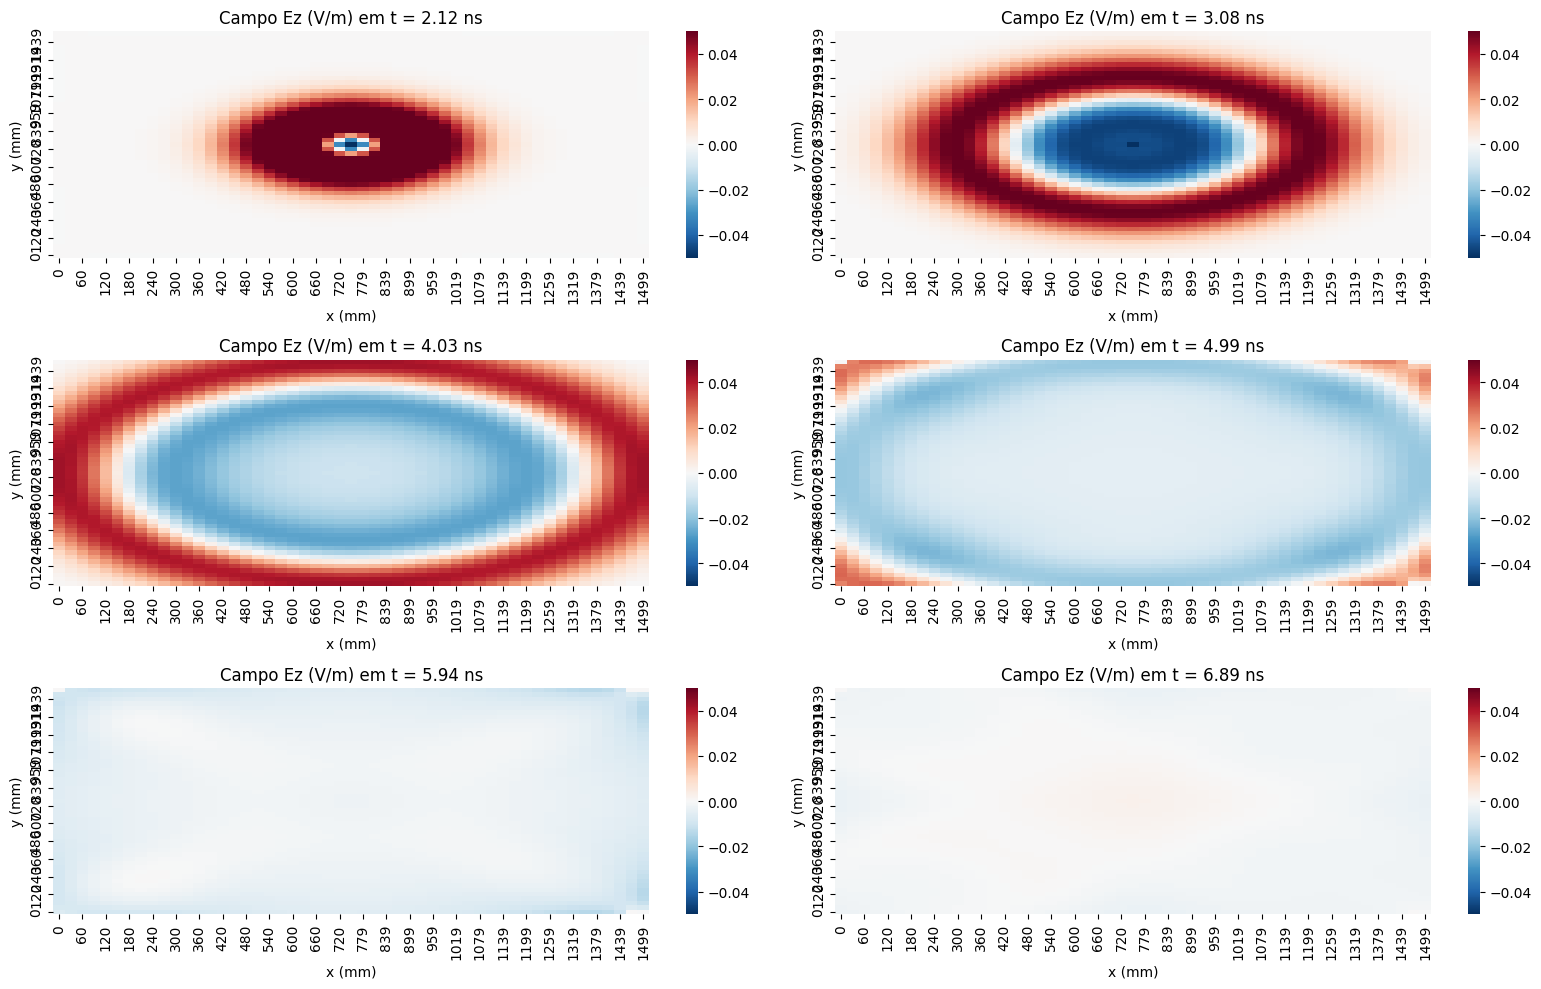

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

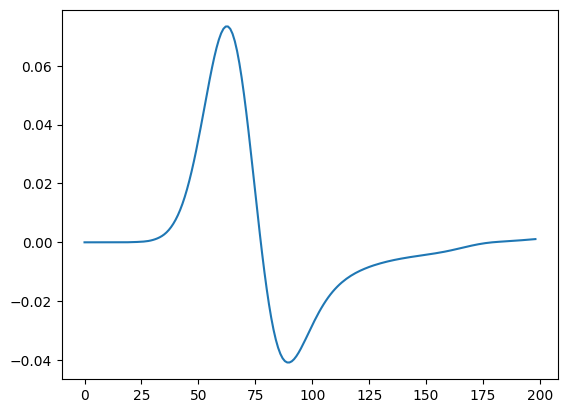

In [25]:
plt.plot(probe)